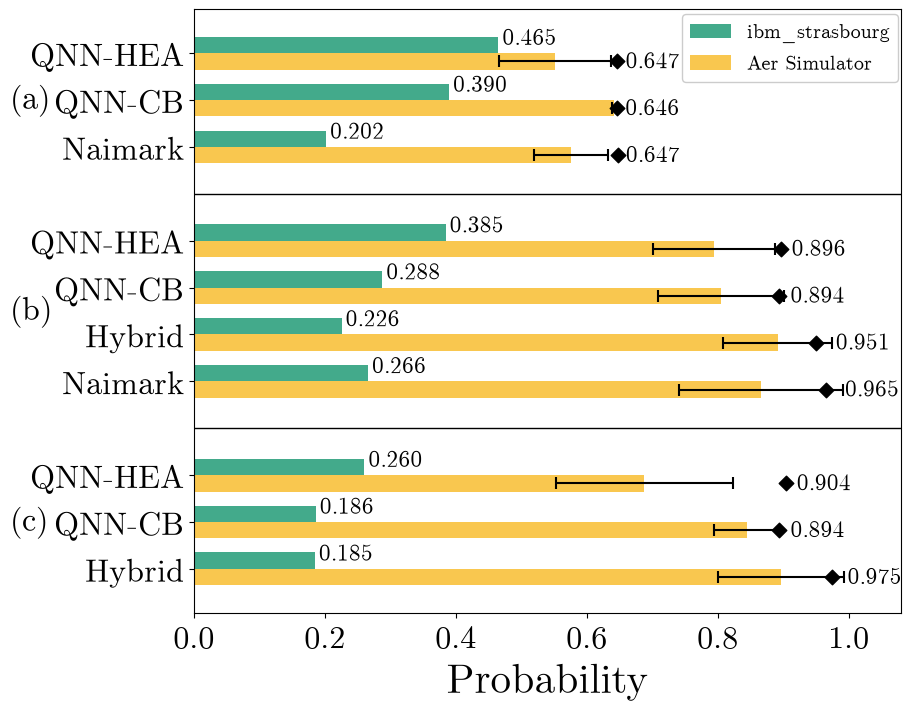

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'CMU Serif',
    'mathtext.fontset': 'cm',
})


# Vibrant tones
color1 = '#f9c74f'   # simulator mean
color2 = '#43aa8b'   # real device

scale_factor = 1.642

font_size = 18 * scale_factor
font_size_bar = 10 * scale_factor
font_size_legend = 10.5 * scale_factor
font_size_cases = 14 * scale_factor

cases = [
    'QNN-HEA', 'QNN-CB', 'Naimark',
    'QNN-HEA', 'QNN-CB', 'Hybrid', 'Naimark',
    'QNN-HEA', 'QNN-CB', 'Hybrid'
]

simulator_max = [0.6468, 0.6464, 0.6472, 0.8962, 0.8944, 0.9509, 0.9649, 0.9040, 0.8944, 0.9752] 
simulator_std = [0.08492, 0.00349, 0.05682, 0.09370, 0.09586, 0.08311, 0.12492, 0.13492, 0.04991, 0.09571]
simulator_mean = [0.5516, 0.6422, 0.5759, 0.7943, 0.8051, 0.8914, 0.8659, 0.6881, 0.8450, 0.8967]
#real_device_results = [0.5161, 0.4061, 0.2179, 0.3844, 0.3099, 0.2687, 0.2347, 0.2955, 0.2516, 0.2239]
real_device_results = [0.4650, 0.3897, 0.2019, 0.3845, 0.2877, 0.2256, 0.2659, 0.2604, 0.1861, 0.1847]


# ---------------------------------------------------------
# Reverse everything so the desired group appears at top
# ---------------------------------------------------------
cases = cases[::-1]
simulator_max = np.array(simulator_max[::-1])
simulator_std = np.array(simulator_std[::-1])
simulator_mean = np.array(simulator_mean[::-1])
real_device_results = np.array(real_device_results[::-1])


# Group spacing
y = np.array([0, 1, 2,
              4, 5, 6, 7,
              9, 10, 11])

height = 0.35

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)


# ---------------------------------------------------------
# Real-device bars
# ---------------------------------------------------------
bars_real = ax.barh(
    y + height / 2,
    real_device_results,
    height,
    label='ibm_strasbourg',
    color=color2
)


# ---------------------------------------------------------
# Simulator MEAN bars
# with STD as error bars
# ---------------------------------------------------------
bars_sim = ax.barh(
    y - height / 2,
    simulator_mean,
    height,
    xerr=simulator_std,
    capsize=4,
    error_kw={
        'elinewidth': 1.5,
        'capthick': 1.5,
        'ecolor': 'black'
    },
    label=r'Aer Simulator',
    color=color1
)


# ---------------------------------------------------------
# Simulator MAX
# Diamond marker at maximum value
# ---------------------------------------------------------
ax.scatter(
    simulator_max,
    y - height / 2,
    marker='D',
    s=55,
    color='black',
    zorder=5,
    label='_nolegend_'
)


# ---------------------------------------------------------
# Axes
# ---------------------------------------------------------
ax.set_xlabel('Probability', fontsize=font_size)

ax.set_yticks(y)
ax.set_yticklabels(cases, fontsize=font_size_cases)

ax.tick_params(axis='x', labelsize=font_size_cases)

# Probability range
ax.set_xlim(0, 1.08)


# ---------------------------------------------------------
# Separator lines
# ---------------------------------------------------------
ax.axhline(8, color='black', linestyle='-', linewidth=1)
ax.axhline(3, color='black', linestyle='-', linewidth=1)


# ---------------------------------------------------------
# Mean value labels
# ---------------------------------------------------------
'''sim_mean_label_offsets = [
    (3, -11),   # label 0
    (-7, -13),   # label TT CB
    (3, -11),   # label 2
    (0, -11),   # label DT QNN
    (-6, -13),   # label DT Hybrid
    (0, -11),   # label DT CB
    (0, -11),   # label DT QNN
    (-10, -14),   # label Sym Hybrid
    (-18, -14),   # label Sym CB
    (1, -10),   # label Sym QNN
]

for i, bar in enumerate(bars_sim):
    w = bar.get_width()

    ax.annotate(
        f'{w:.3f}',
        xy=(w, bar.get_y() + bar.get_height() / 2),
        xytext=sim_mean_label_offsets[i],
        textcoords='offset points',
        va='center',
        fontsize=font_size_bar
    )'''

# ---------------------------------------------------------
# Real-device value labels
# ---------------------------------------------------------
for bar in bars_real:
    w = bar.get_width()

    ax.annotate(
        f'{w:.3f}',
        xy=(w, bar.get_y() + bar.get_height() / 2),
        xytext=(3, 5),
        textcoords='offset points',
        va='center',
        fontsize=font_size_bar
    )


# ---------------------------------------------------------
# Optional MAX value labels
# ---------------------------------------------------------
max_label_offsets = [
    (11, 0),   # label TT Hybrid
    (8, 0),   # label TT
    (8, 0),   # label TT Hybrid
    (14, 0),   # label DT Nymark
    (14, 0),   # label DT Hybrid
    (8, 0),   # label 5
    (8, 0),   # label 6
    (6, 0),   # label Sym Naimark
    (6, 0),   # label Sym CB
    (6, 0),   # label Sym QNN
]

for i, (x_max, y_pos) in enumerate(zip(simulator_max, y - height/2)):
    ax.annotate(
        f'{x_max:.3f}',
        xy=(x_max, y_pos),
        xytext=max_label_offsets[i],
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=font_size_bar 
    )


# ---------------------------------------------------------
# Group labels
# ---------------------------------------------------------
ax.text(
    -0.26, 10, '(a)',
    transform=ax.get_yaxis_transform(),
    fontsize=font_size_cases,
    va='center'
)

ax.text(
    -0.26, 5.5, '(b)',
    transform=ax.get_yaxis_transform(),
    fontsize=font_size_cases,
    va='center'
)

ax.text(
    -0.26, 1, '(c)',
    transform=ax.get_yaxis_transform(),
    fontsize=font_size_cases,
    va='center'
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------
ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.01, 1.01),
    fontsize=font_size_legend - 2.5,
    frameon=True,
    fancybox=True,
    framealpha=1.0
)


plt.savefig(
    'ME_Graph2.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()